# AML s26 - KNN Classifier 

### Import Libraries

In [13]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


### Load and visualize data 

In [14]:
df = pd.read_csv('knn_dataset_A.csv')

print("Shape:", df.shape)
print(df.head(5))

Shape: (500, 3)
   feature_1  feature_2 label
0   2.736928   1.380405     B
1   2.239011   0.167232     B
2   1.661672  -0.427913     B
3  -1.458047   3.325565     A
4   2.321741  -0.058554     B


### Generate class statistics for the complete data set 

In [15]:
df_y = df.label
df_y.value_counts()


label
A    240
B    150
C     75
D     35
Name: count, dtype: int64

### Get the feature vectors  

In [16]:
df_X = df.drop('label', axis=1)
df_X.head(5)

,feature_1,feature_2
0,2.736928,1.380405
1,2.239011,0.167232
2,1.661672,-0.427913
3,-1.458047,3.325565
4,2.321741,-0.058554


### Train-Test split 

Note we have options ... this is important! Why?

In [17]:
naive = False

state = 932    # None

if naive:
    (X_train, X_test, y_train, y_test) = train_test_split(np.asarray(df_X), df_y,                test_size=0.3, random_state=state)
else:
    (X_train, X_test, y_train, y_test) = train_test_split(np.asarray(df_X), df_y, stratify=df_y, test_size=0.3, random_state=state)

y_test.value_counts()
 


label
A    72
B    45
C    23
D    10
Name: count, dtype: int64

### Standardize features 

In [18]:
scaler = StandardScaler(with_mean=True, with_std=True, copy=True)

scaler.fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)



### Train KNN classifier and get test error rate 

In [19]:
k=1
knn1 = KNeighborsClassifier(n_neighbors=k)

y_pred = knn1.fit(X_train_std, y_train).predict(X_test_std)

print(f"Error rate:  {np.mean(y_test != y_pred):.4f}")

Error rate:  0.2667


### Generate a confusion matrix to show misclassification per category 

In [20]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[59 11  2  0]
 [ 9 30  0  6]
 [ 8  0 15  0]
 [ 1  1  2  6]]


### Now with nicer looks ...


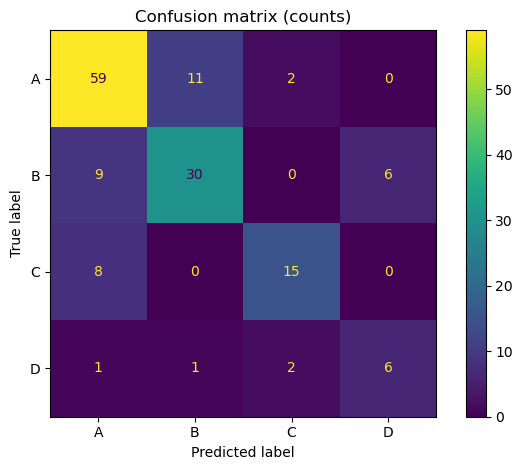

In [21]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion matrix (counts)")
plt.tight_layout()
plt.show()

### Now normalized ... 

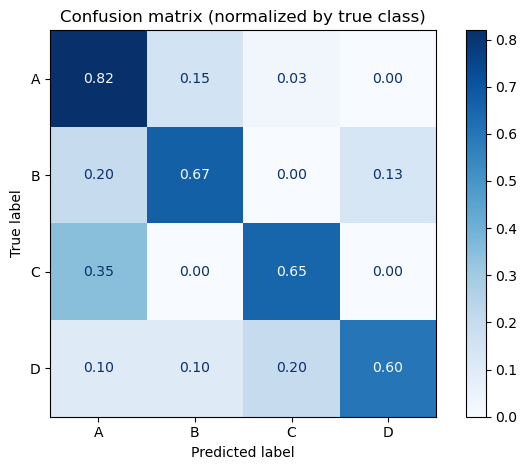

In [22]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true", values_format=".2f", cmap="Blues", colorbar=True)

disp.ax_.set_title("Confusion matrix (normalized by true class)")
plt.tight_layout()
plt.show()

### Get the test error as a function of K 

In [23]:
all_k =[]
all_err=[]

max_K = 20
for K in range(1,max_K+1):
    knn = KNeighborsClassifier(n_neighbors=K)
    
    y_pred = knn.fit(X_train_std, y_train).predict(X_test_std)
    error = np.mean(y_test != y_pred)
    print(f"k: {K}   Error rate:  {error:.4f}")
    
    all_k.append(K)
    all_err.append(error)



k: 1   Error rate:  0.2667
k: 2   Error rate:  0.2733
k: 3   Error rate:  0.2600
k: 4   Error rate:  0.2800
k: 5   Error rate:  0.2533
k: 6   Error rate:  0.2533
k: 7   Error rate:  0.2267
k: 8   Error rate:  0.2267
k: 9   Error rate:  0.2333
k: 10   Error rate:  0.2333
k: 11   Error rate:  0.2133
k: 12   Error rate:  0.2067
k: 13   Error rate:  0.2067
k: 14   Error rate:  0.2067
k: 15   Error rate:  0.1867
k: 16   Error rate:  0.2200
k: 17   Error rate:  0.2067
k: 18   Error rate:  0.2133
k: 19   Error rate:  0.2067
k: 20   Error rate:  0.2133


## Plot test error rate as a function of K

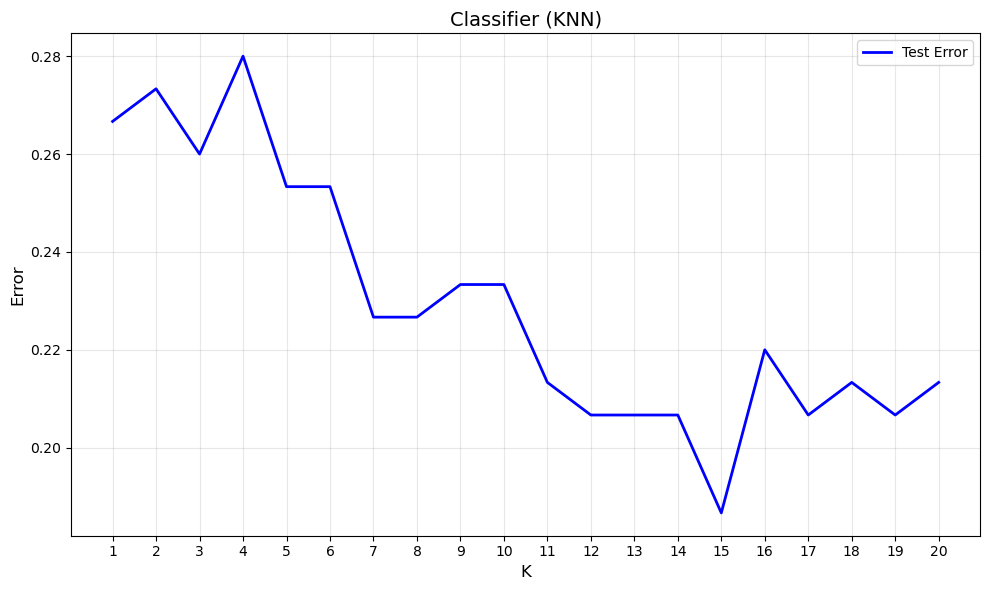

In [24]:
plt.figure(1, figsize=(10, 6))

plt.plot(all_k, all_err, linewidth=2, label="Test Error", color='blue')
plt.xlabel("K", fontsize=12)
plt.ylabel("Error", fontsize=12)
plt.title(f"Classifier (KNN)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(1, max_K+1, 1))
plt.tight_layout()
plt.show()